# Loan Approval – ANN Classification
End-to-end pipeline: EDA → preprocessing → ANN training → evaluation.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
print("TF version:", tf.__version__)


TF version: 2.13.0


## 1. Load Data

In [2]:
DATA_PATH = (
    "https://raw.githubusercontent.com/upflairs-pvt-ltd/JECRC-20april2024/main/loan%20aproaval%20DL/loan_approval_dataset.csv"
)
df = pd.read_csv(DATA_PATH, skipinitialspace=True)

# Strip leading/trailing whitespace from column names
df.columns = [c.strip() for c in df.columns]

print(df.shape)
df.head()


(4269, 13)


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


## 2. Exploratory Data Analysis

In [3]:
print("Columns:", df.columns.tolist())
print()
print(df.dtypes)
print()
print(df.isnull().sum())


Columns: ['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']

loan_id                      int64
no_of_dependents             int64
education                   object
self_employed               object
income_annum                 int64
loan_amount                  int64
loan_term                    int64
cibil_score                  int64
residential_assets_value     int64
commercial_assets_value      int64
luxury_assets_value          int64
bank_asset_value             int64
loan_status                 object
dtype: object

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_asset

In [4]:
print("loan_status distribution:")
print(df['loan_status'].value_counts())
print()
print("education distribution:")
print(df['education'].value_counts())
print()
print("self_employed distribution:")
print(df['self_employed'].value_counts())


loan_status distribution:
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

education distribution:
education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

self_employed distribution:
self_employed
Yes    2150
No     2119
Name: count, dtype: int64


In [5]:
print("Loan status by employment type:")
print(df.groupby(['self_employed', 'loan_status']).size().unstack(fill_value=0))


Loan status by employment type:
loan_status    Approved  Rejected
self_employed                    
No                 1318       801
Yes                1338       812


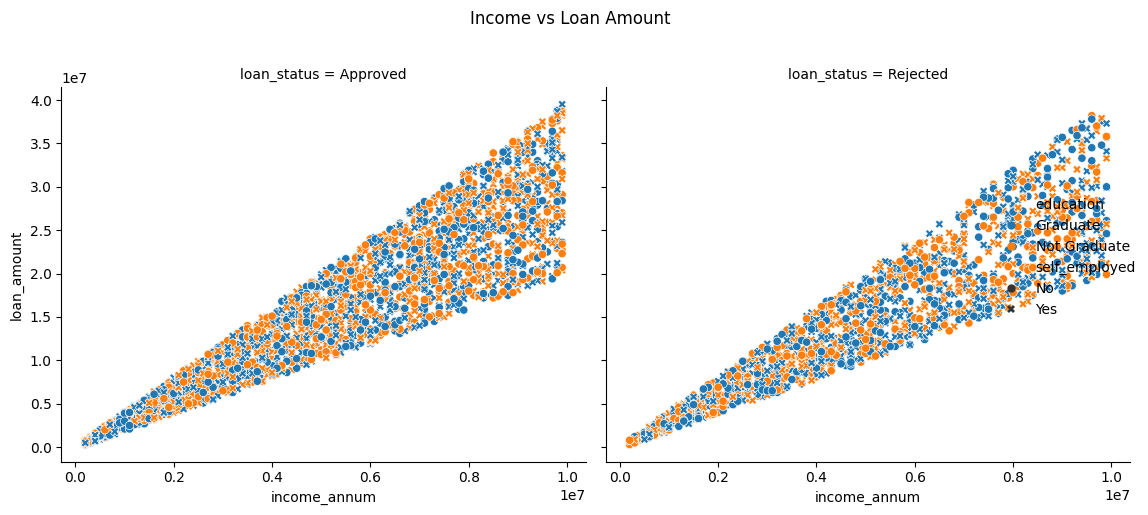

In [6]:
sns.relplot(
    x='income_annum', y='loan_amount', data=df,
    hue='education', style='self_employed', col='loan_status'
)
plt.suptitle("Income vs Loan Amount", y=1.02)
plt.tight_layout()
plt.show()


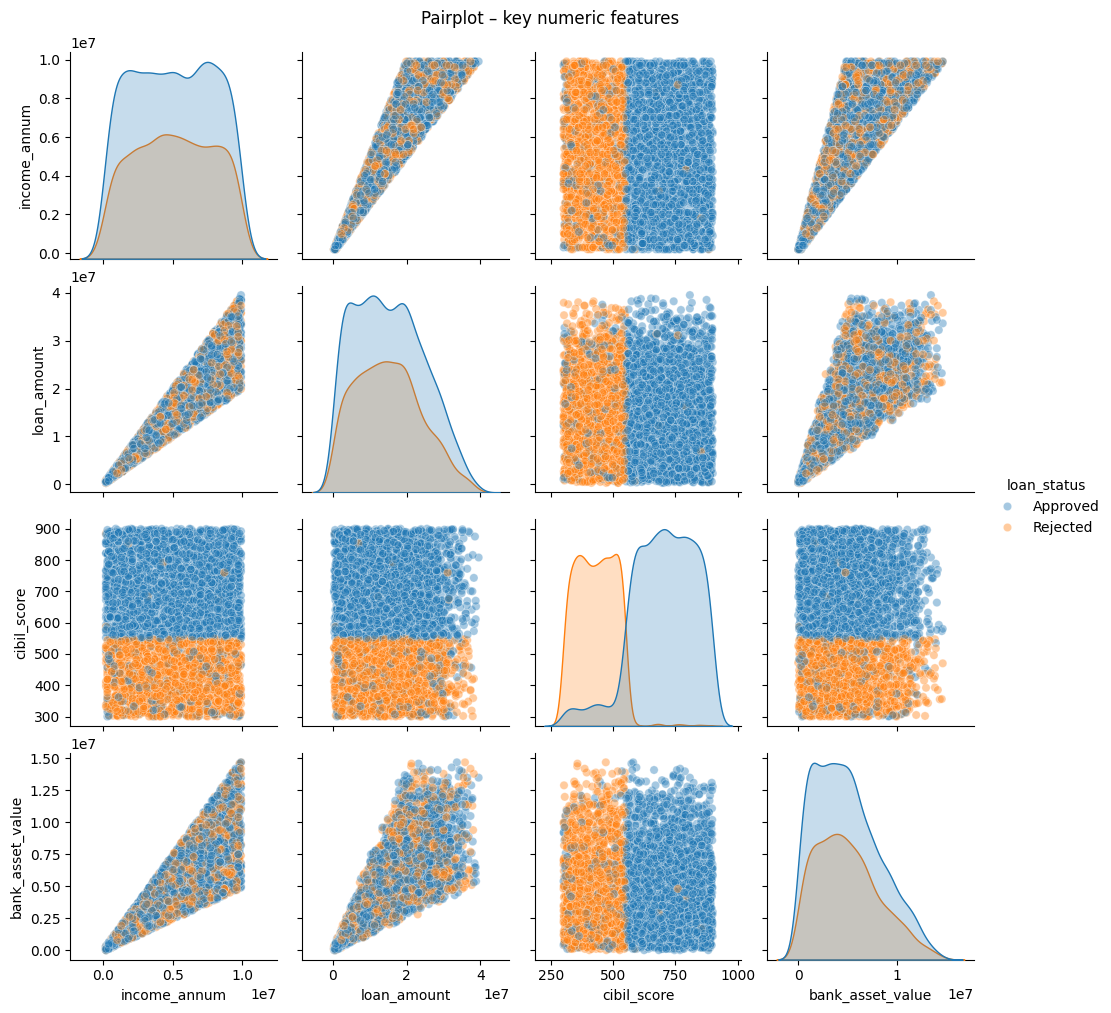

In [7]:
# Pairplot on numeric columns only (fast version)
numeric_cols = ['income_annum', 'loan_amount', 'cibil_score',
                'bank_asset_value', 'loan_status']
sns.pairplot(
    df[numeric_cols].assign(loan_status=df['loan_status']),
    hue='loan_status', plot_kws={'alpha': 0.4}
)
plt.suptitle("Pairplot – key numeric features", y=1.01)
plt.show()


## 3. Preprocessing

In [8]:
# Drop ID column – not a feature
df_clean = df.drop('loan_id', axis=1).copy()

# Encode target: Approved → 1, Rejected → 0
df_clean['loan_status'] = df_clean['loan_status'].map({'Approved': 1, 'Rejected': 0})

# One-hot encode categorical columns (drop_first avoids multicollinearity)
df_clean = pd.get_dummies(df_clean, drop_first=True)

print("Shape after encoding:", df_clean.shape)
print(df_clean.columns.tolist())
df_clean.head()


Shape after encoding: (4269, 12)
['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status', 'education_Not Graduate', 'self_employed_Yes']


,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_Not Graduate,self_employed_Yes
0,2,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1,False,False
1,0,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,True,True
2,3,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,False,False
3,3,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,False,False
4,5,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,True,True


In [9]:
X = df_clean.drop('loan_status', axis=1)
y = df_clean['loan_status']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features:", X.shape[1])
print("Class balance:", y.value_counts().to_dict())


Features: 11
Class balance: {1: 2656, 0: 1613}


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "  Test:", X_test.shape)


Train: (3415, 11)   Test: (854, 11)


## 4. ANN Model

In [11]:
n_features = X_train.shape[1]  # dynamic – never hardcode

Ann_model = Sequential([
    Dense(64, activation='relu', input_dim=n_features),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1,  activation='sigmoid')   # binary output
])

Ann_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

Ann_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                768       
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 16)                528       
                                                                 
 dense_3 (Dense)             (None, 1)                 17        
                                                                 
Total params: 3393 (13.25 KB)
Trainable params: 3393 (13

In [12]:
early_stop = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
)

history = Ann_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
107/107 [==============================] - 1s 4ms/step - loss: 0.5601 - accuracy: 0.7139 - val_loss: 0.2914 - val_accuracy: 0.9075
Epoch 2/50
107/107 [==============================] - 0s 2ms/step - loss: 0.2852 - accuracy: 0.8820 - val_loss: 0.1794 - val_accuracy: 0.9379
Epoch 3/50
107/107 [==============================] - 0s 2ms/step - loss: 0.2482 - accuracy: 0.8990 - val_loss: 0.1679 - val_accuracy: 0.9415
Epoch 4/50
107/107 [==============================] - 0s 2ms/step - loss: 0.2253 - accuracy: 0.9089 - val_loss: 0.1613 - val_accuracy: 0.9438
Epoch 5/50
107/107 [==============================] - 0s 3ms/step - loss: 0.2079 - accuracy: 0.9218 - val_loss: 0.1570 - val_accuracy: 0.9391
Epoch 6/50
107/107 [==============================] - 0s 3ms/step - loss: 0.2091 - accuracy: 0.9183 - val_loss: 0.1440 - val_accuracy: 0.9450
Epoch 7/50
107/107 [==============================] - 0s 3ms/step - loss: 0.1906 - accuracy: 0.9280 - val_loss: 0.1449 - val_accuracy: 0.9379
Epoch 

## 5. Training Curves

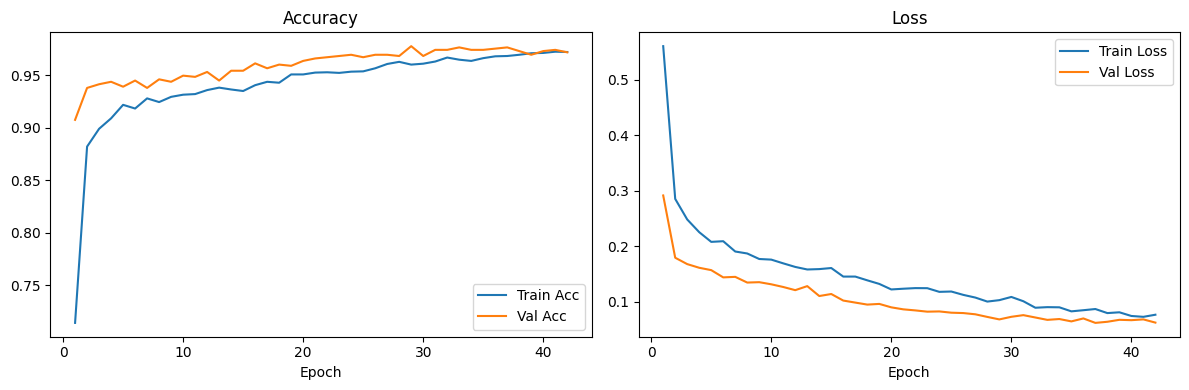

In [13]:
history_df = pd.DataFrame(history.history)
history_df.index += 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df['accuracy'],     label='Train Acc')
axes[0].plot(history_df['val_accuracy'], label='Val Acc')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_df['loss'],     label='Train Loss')
axes[1].plot(history_df['val_loss'], label='Val Loss')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Model Evaluation

In [14]:
loss, accuracy = Ann_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss:     {loss:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")


Test Loss:     0.0621
Test Accuracy: 97.66%


27/27 [==============================] - 0s 769us/step


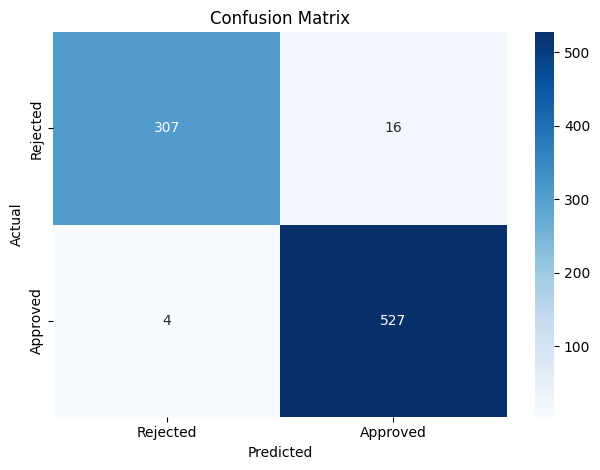

In [15]:
y_prob = Ann_model.predict(X_test).ravel()
y_pred = (y_prob > 0.5).astype(int)   # single consistent threshold

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected','Approved'],
            yticklabels=['Rejected','Approved'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


In [16]:
print(classification_report(y_test, y_pred, target_names=['Rejected', 'Approved']))


              precision    recall  f1-score   support

    Rejected       0.99      0.95      0.97       323
    Approved       0.97      0.99      0.98       531

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.97       854
weighted avg       0.98      0.98      0.98       854



## 7. Baseline Comparison – Random Forest

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print(f"RF Train Accuracy: {rf.score(X_train, y_train)*100:.2f}%")
print(f"RF Test  Accuracy: {rf.score(X_test,  y_test )*100:.2f}%")


RF Train Accuracy: 100.00%
RF Test  Accuracy: 98.13%


## 8. Save & Reload Model

In [18]:
import os
os.makedirs('models', exist_ok=True)
Ann_model.save('./models/ann_model.h5')
print("Model saved to ./models/ann_model.h5")


Model saved to ./models/ann_model.h5


In [19]:
from tensorflow.keras.models import load_model
loaded_model = load_model('./models/ann_model.h5')
loaded_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                768       
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 16)                528       
                                                                 
 dense_3 (Dense)             (None, 1)                 17        
                                                                 
Total params: 3393 (13.25 KB)
Trainable params: 3393 (13

In [20]:
import pickle, os
os.makedirs('models', exist_ok=True)

# Save the scaler
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Scaler saved to models/scaler.pkl")

Scaler saved to models/scaler.pkl
